# Decision Tree Classification

## Objective

This notebook demonstrates the implementation of a Decision Tree Classifier using the Titanic Dataset.

Goals:

- Understand Decision Tree Classification.
- Learn Entropy and Gini-based splitting.
- Train a Decision Tree model.
- Evaluate classification performance.
- Interpret model predictions.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load Dataset

df = pd.read_csv(
    "dataset/Titanic-Dataset.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Dataset Information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# First 5 Rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Data Types

print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [6]:
# Check Missing Values

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
# Remove unnecessary columns

df = df.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket',
        'Cabin'
    ],
    errors='ignore'
)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [8]:
# Fill Age with Median

df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

# Fill Embarked with Mode

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [9]:
# Convert categorical columns

df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df['Embarked'] = df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [10]:
# Features and Target

X = df.drop(
    'Survived',
    axis=1
)

y = df['Survived']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (891, 7)
Target Shape: (891,)


In [11]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 712
Testing Samples: 179


In [12]:
# Train Decision Tree

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


In [13]:
# Make Predictions

y_pred = dt_model.predict(
    X_test
)

print("Predictions Generated Successfully.")

Predictions Generated Successfully.


In [14]:
# Model Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.7877


In [15]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.76      0.95      0.85       110
           1       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



In [16]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[104   6]
 [ 32  37]]


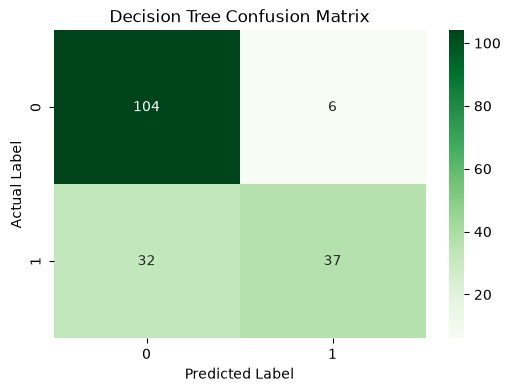

In [17]:
# Confusion Matrix Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.show()

In [18]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Sex,0.576297
0,Pclass,0.195920
2,Age,0.123665
5,Fare,0.054002
6,Embarked,0.037198
3,SibSp,0.012109
4,Parch,0.000809


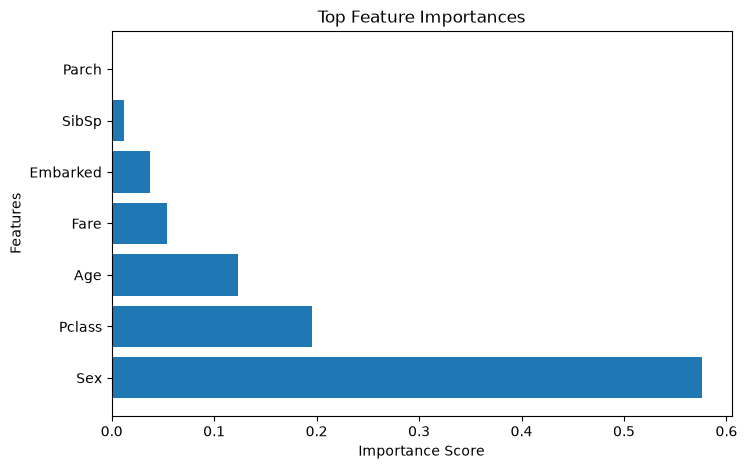

In [19]:
# Feature Importance Plot

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.title(
    "Top Feature Importances"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.show()

# Model Interpretation

Observations:

- The Decision Tree successfully learned patterns from passenger information.
- Features such as Sex, Fare, Pclass, and Age contributed significantly to predictions.
- The model provides interpretable decision rules.
- Limiting tree depth helped reduce overfitting.

Conclusion:

Decision Trees are highly interpretable supervised learning models and are useful when understanding the reasoning behind predictions is important.

# Interview Notes

Q1. Why do Decision Trees overfit?

Answer:
Decision Trees can create very deep structures that memorize training data instead of learning general patterns.

Q2. What is Entropy?

Answer:
Entropy measures impurity or randomness in a dataset.

Q3. What is Information Gain?

Answer:
Information Gain measures how much uncertainty is reduced after splitting on a feature.

Q4. Why use Gini Index?

Answer:
Gini Index is computationally efficient and commonly used to determine the best split.

Q5. What is pruning?

Answer:
Pruning removes unnecessary branches to reduce overfitting and improve generalization.

# Key Takeaways

- Decision Trees use recursive splitting.
- Entropy and Gini measure impurity.
- Information Gain selects the best feature.
- Pruning helps control overfitting.
- Decision Trees are easy to interpret and explain.